# 03 — Dataset de Emparejamiento por Preferencia (ParetoDataset)

Tercer notebook del pipeline tracked. Toma los grafos de `data/graphs/` (notebook 02)
y los frentes de Pareto limpios de `data/baselines/clean/` (notebook 01), y arma el
dataset de entrenamiento del PHN-GNN.

Empareja cada instancia (grafo + frente de Pareto) con vectores de preferencia muestreados al azar.
Para cada `r = (r_cov, r_cost)` aplica **dynamic matching**: selecciona la solución del frente que minimiza

$$s(\mathbf{y}, \mathbf{r}) = r_{\text{cov}}\,\bigl(1 - \tfrac{\text{cov}}{\text{cov}_{\max}}\bigr) + r_{\text{cost}}\,\tfrac{\text{cost}}{n_{\text{cand}}}$$

Devuelve un `torch_geometric.data.Data` con `.r` y `.y_star` adjuntos, listo para el `DataLoader`.

In [1]:
import json
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt

print(f"torch      {torch.__version__}")
import torch_geometric; print(f"pyg        {torch_geometric.__version__}")

torch      2.12.1+cpu
pyg        2.8.0


In [2]:
ROOT       = Path("..")              # c:/INF 577/PROYECTO
GRAPH_DIR  = ROOT / "data" / "graphs"
PARETO_DIR = ROOT / "data" / "baselines" / "clean"
SPLIT_FILE = GRAPH_DIR / "split.json"

with open(SPLIT_FILE) as f:
    split = json.load(f)

for k, v in split.items():
    print(f"  {k:20s}: {len(v):4d} instancias")

  train               :  800 instancias
  val                 :  100 instancias
  test_phub           :  100 instancias
  test_clustering     :    9 instancias
  test_cdmx           :   16 instancias


## Clase ParetoDataset

In [3]:
class ParetoDataset(Dataset):
    """
    Dataset que combina grafo de proximidad + frente de Pareto.

    Parámetros
    ----------
    instance_names : list[str]
        Lista del formato "<dataset>/<nombre>", tal como están en split.json.
    graph_dir : Path
        Directorio raíz de los grafos .pt  (graph_dir/<dataset>/<nombre>.pt).
    pareto_dir : Path
        Directorio raíz de los frentes limpios (pareto_dir/<dataset>/<nombre>/objectives.npy).
    n_pref : int
        Vectores de preferencia muestreados por instancia por época.
    seed : int | None
        Semilla del generador aleatorio (None → no reproducible).
    """

    def __init__(self, instance_names, graph_dir, pareto_dir, n_pref=1, seed=None):
        super().__init__()
        self.n_pref = n_pref
        self.rng    = np.random.default_rng(seed)

        self.instances = []
        missing = []
        for name in instance_names:
            g_path = Path(graph_dir) / (name + ".pt")
            o_path = Path(pareto_dir) / name / "objectives.npy"
            s_path = Path(pareto_dir) / name / "solutions.npy"

            if not g_path.exists() or not o_path.exists():
                missing.append(name)
                continue

            graph = torch.load(g_path, weights_only=False)
            obj   = np.load(o_path)   # (n_pareto, 2)  float64
            sol   = np.load(s_path)   # (n_pareto, N_total)  int8

            self.instances.append({
                "name": name,
                "graph": graph,
                "objectives": obj,
                "solutions":  sol,
            })

        if missing:
            print(f"ADVERTENCIA: {len(missing)} instancias no encontradas → {missing[:3]}...")
        print(f"Cargadas {len(self.instances)} instancias × {n_pref} pref = {len(self)} muestras/época")

    # ------------------------------------------------------------------
    # Interfaz Dataset
    # ------------------------------------------------------------------

    def __len__(self):
        return len(self.instances) * self.n_pref

    def __getitem__(self, idx):
        inst  = self.instances[idx % len(self.instances)]
        graph = inst["graph"]

        r      = self._sample_r()
        y_star = self._dynamic_match(inst["objectives"], inst["solutions"], r, graph)

        data = Data(
            x          = graph.x,           # (N_total, 3)  [flag, prob, degree]
            edge_index = graph.edge_index,  # (2, E)
        )
        # Metadata de la instancia
        data.instance_name = graph.instance_name
        data.n_candidates  = graph.n_candidates   # P (budget ≈ N_total − preinstalled)
        data.cov_max       = graph.cov_max
        data.n_pareto      = graph.n_pareto

        # Supervisión
        data.r      = torch.tensor(r,      dtype=torch.float)  # (2,)
        data.y_star = torch.tensor(y_star, dtype=torch.float)  # (N_total,)

        return data

    # ------------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------------

    def _sample_r(self):
        """Muestrea r uniformemente del 1-símplex: r_cov + r_cost = 1."""
        r1 = self.rng.uniform(0.0, 1.0)
        return np.array([r1, 1.0 - r1], dtype=np.float32)

    def _dynamic_match(self, objectives, solutions, r, graph):
        """
        Devuelve el vector binario y* del frente que minimiza s(y, r).

        objectives[:, 0] = f1 = −cobertura  (MINIMIZAR)
        objectives[:, 1] = f2 = costo       (MINIMIZAR)
        """
        coverage = -objectives[:, 0]               # cobertura real (positiva)
        cost     =  objectives[:, 1]

        cov_norm  = coverage / float(graph.cov_max)
        cost_norm = cost     / float(graph.n_candidates)

        scores   = r[0] * (1.0 - cov_norm) + r[1] * cost_norm
        best_idx = int(np.argmin(scores))

        return solutions[best_idx].astype(np.float32)  # (N_total,)

    # ------------------------------------------------------------------
    # Acceso a metadatos para debugging
    # ------------------------------------------------------------------

    def pareto_info(self, idx):
        """Muestra el frente de Pareto de la instancia idx."""
        inst = self.instances[idx % len(self.instances)]
        obj  = inst["objectives"]
        print(f"Instancia : {inst['name']}")
        print(f"Puntos    : {len(obj)}")
        print(f"{'Cobertura':>12}  {'Costo':>6}  {'cov_norm':>9}  {'cost_norm':>9}")
        g = inst["graph"]
        for f1, f2 in obj:
            cov = -f1
            cn  = cov / g.cov_max
            sn  = f2  / g.n_candidates
            print(f"  {cov:10.4f}  {f2:6.0f}  {cn:9.4f}  {sn:9.4f}")

## Instanciar train / val / test

In [4]:
N_PREF_TRAIN = 10   # 10 preferencias × 150 instancias = 1 500 muestras/época
N_PREF_EVAL  = 1

ds_train = ParetoDataset(
    split["train"], GRAPH_DIR, PARETO_DIR, n_pref=N_PREF_TRAIN, seed=42
)
ds_val = ParetoDataset(
    split["val"], GRAPH_DIR, PARETO_DIR, n_pref=N_PREF_EVAL, seed=0
)
ds_test_clust = ParetoDataset(
    split["test_clustering"], GRAPH_DIR, PARETO_DIR, n_pref=N_PREF_EVAL, seed=0
)
ds_test_cdmx = ParetoDataset(
    split["test_cdmx"], GRAPH_DIR, PARETO_DIR, n_pref=N_PREF_EVAL, seed=0
)

Cargadas 800 instancias × 10 pref = 8000 muestras/época
Cargadas 100 instancias × 1 pref = 100 muestras/época
Cargadas 9 instancias × 1 pref = 9 muestras/época
ADVERTENCIA: 1 instancias no encontradas → ['cdmx/cam_40264_IZTAPALAPA']...
Cargadas 15 instancias × 1 pref = 15 muestras/época


## Inspeccionar una muestra

In [5]:
sample = ds_train[0]
print(sample)
print()
print(f"Instancia  : {sample.instance_name}")
print(f"x          : {tuple(sample.x.shape)}  (N_total × 3 features)")
print(f"edge_index : {tuple(sample.edge_index.shape)}")
print(f"r          : {sample.r.tolist()}")
print(f"y_star     : shape={tuple(sample.y_star.shape)}  sum={sample.y_star.sum():.0f} cámaras")
print(f"n_pareto   : {sample.n_pareto}")
print(f"cov_max    : {sample.cov_max:.4f}")
print(f"n_cand     : {sample.n_candidates}")

# Verificar el score de la solución elegida
cov_norm  = sample.y_star.sum().item() / sample.cov_max   # aprox (es la suma de flags, no la cobertura ponderada)
print(f"\n(Nota: y_star.sum()={sample.y_star.sum():.0f} = cámaras instaladas incluyendo preinstaladas)")

Data(x=[150, 3], edge_index=[2, 942], instance_name='wsc_981_R0p1208_pre6', n_candidates=144, cov_max=27.9119, n_pareto=19, r=[2], y_star=[150])

Instancia  : wsc_981_R0p1208_pre6
x          : (150, 3)  (N_total × 3 features)
edge_index : (2, 942)
r          : [0.7739560604095459, 0.2260439544916153]
y_star     : shape=(150,)  sum=24 cámaras
n_pareto   : 19
cov_max    : 27.9119
n_cand     : 144

(Nota: y_star.sum()=24 = cámaras instaladas incluyendo preinstaladas)


In [6]:
# Ver el frente completo de la instancia 0
ds_train.pareto_info(0)

Instancia : phub/wsc_981_R0p1208_pre6
Puntos    : 19
   Cobertura   Costo   cov_norm  cost_norm
      5.5305       0     0.1981     0.0000
      9.4741       1     0.3394     0.0069
     11.7074       2     0.4194     0.0139
     13.7070       3     0.4911     0.0208
     15.5028       4     0.5554     0.0278
     20.2466       7     0.7254     0.0486
     23.1232       9     0.8284     0.0625
     24.3233      10     0.8714     0.0694
     25.2751      11     0.9055     0.0764
     25.9649      12     0.9302     0.0833
     26.4969      13     0.9493     0.0903
     26.8193      14     0.9609     0.0972
     27.4092      16     0.9820     0.1111
     27.6856      17     0.9919     0.1181
     27.8085      18     0.9963     0.1250
     27.8618      19     0.9982     0.1319
     27.8858      20     0.9991     0.1389
     27.9026      21     0.9997     0.1458
     27.9119      22     1.0000     0.1528


## DataLoader y batch

In [7]:
BATCH_SIZE = 8

loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Inspeccionar el primer batch
batch = next(iter(loader_train))
print(batch)
print()
print(f"batch.x          : {tuple(batch.x.shape)}     ← todos los nodos del batch concatenados")
print(f"batch.edge_index : {tuple(batch.edge_index.shape)}")
print(f"batch.r          : {tuple(batch.r.shape)}         ← necesita reshape a (B, 2)")
print(f"batch.y_star     : {tuple(batch.y_star.shape)}    ← nodos concatenados")
print(f"batch.batch      : {tuple(batch.batch.shape)}     ← qué grafo pertenece cada nodo")

# r está aplanado como (B*2,) → necesita reshape
r_batch = batch.r.view(BATCH_SIZE, 2)
print(f"\nr_batch (reshape): {tuple(r_batch.shape)}")
print(r_batch)

DataBatch(x=[1200, 3], edge_index=[2, 11730], instance_name=[8], n_candidates=[8], cov_max=[8], n_pareto=[8], r=[16], y_star=[1200], batch=[1200], ptr=[9])

batch.x          : (1200, 3)     ← todos los nodos del batch concatenados
batch.edge_index : (2, 11730)
batch.r          : (16,)         ← necesita reshape a (B, 2)
batch.y_star     : (1200,)    ← nodos concatenados
batch.batch      : (1200,)     ← qué grafo pertenece cada nodo

r_batch (reshape): (8, 2)
tensor([[0.4389, 0.5611],
        [0.8586, 0.1414],
        [0.6974, 0.3026],
        [0.0942, 0.9058],
        [0.9756, 0.0244],
        [0.7611, 0.2389],
        [0.7861, 0.2139],
        [0.1281, 0.8719]])


## Distribución de r en el conjunto de entrenamiento

Verificamos que los vectores de preferencia cubren bien el símplex.

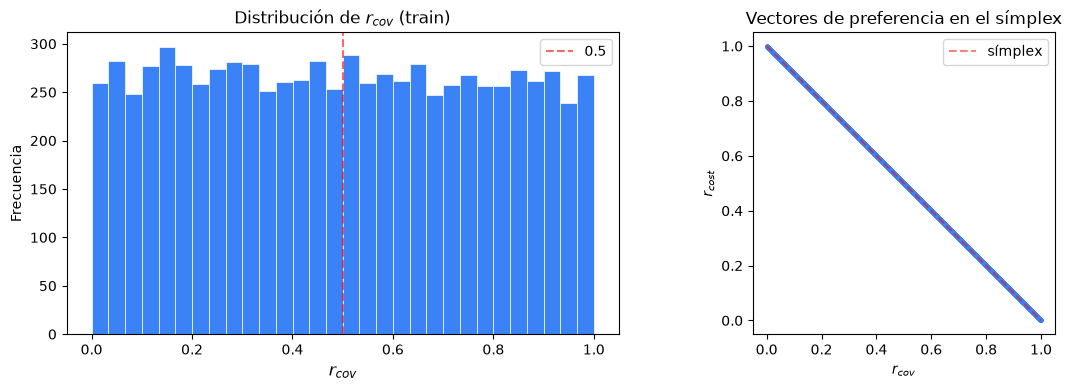

Total de muestras en una época: 8000


In [8]:
# Recoger r de todas las muestras de una época
all_r = []
for b in DataLoader(ds_train, batch_size=64, shuffle=False, num_workers=0):
    all_r.append(b.r.view(-1, 2))
all_r = torch.cat(all_r, dim=0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_r[:, 0], bins=30, color='#3B82F6', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('$r_{cov}$', fontsize=12)
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de $r_{cov}$ (train)')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.6, label='0.5')
axes[0].legend()

axes[1].scatter(all_r[:, 0], all_r[:, 1], s=4, alpha=0.3, color='#3B82F6')
axes[1].plot([0, 1], [1, 0], 'r--', alpha=0.5, label='símplex')
axes[1].set_xlabel('$r_{cov}$')
axes[1].set_ylabel('$r_{cost}$')
axes[1].set_title('Vectores de preferencia en el símplex')
axes[1].set_aspect('equal')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Total de muestras en una época: {len(all_r)}")

## Verificación de dynamic matching

Para un `r` fijo, revisamos que se seleccione la solución correcta del frente.

In [9]:
import numpy as np

inst = ds_train.instances[0]
obj  = inst["objectives"]
g    = inst["graph"]

r_test = np.array([0.5, 0.5], dtype=np.float32)

coverage  = -obj[:, 0]
cost      =  obj[:, 1]
cov_norm  = coverage / g.cov_max
cost_norm = cost / g.n_candidates
scores    = r_test[0] * (1 - cov_norm) + r_test[1] * cost_norm

print(f"Instancia: {inst['name']}")
print(f"{'idx':>4}  {'cov':>8}  {'cost':>5}  {'cov_n':>7}  {'cost_n':>7}  {'score':>7}")
for i, (sc, cov, cs, cn, sn) in enumerate(zip(scores, coverage, cost, cov_norm, cost_norm)):
    marker = " ← MEJOR" if i == np.argmin(scores) else ""
    print(f"  {i:2d}  {cov:8.4f}  {cs:5.0f}  {cn:7.4f}  {sn:7.4f}  {sc:7.4f}{marker}")

Instancia: phub/wsc_981_R0p1208_pre6
 idx       cov   cost    cov_n   cost_n    score
   0    5.5305      0   0.1981   0.0000   0.4009
   1    9.4741      1   0.3394   0.0069   0.3338
   2   11.7074      2   0.4194   0.0139   0.2972
   3   13.7070      3   0.4911   0.0208   0.2649
   4   15.5028      4   0.5554   0.0278   0.2362
   5   20.2466      7   0.7254   0.0486   0.1616
   6   23.1232      9   0.8284   0.0625   0.1170
   7   24.3233     10   0.8714   0.0694   0.0990
   8   25.2751     11   0.9055   0.0764   0.0854
   9   25.9649     12   0.9302   0.0833   0.0765
  10   26.4969     13   0.9493   0.0903   0.0705
  11   26.8193     14   0.9609   0.0972   0.0682
  12   27.4092     16   0.9820   0.1111   0.0646
  13   27.6856     17   0.9919   0.1181   0.0631 ← MEJOR
  14   27.8085     18   0.9963   0.1250   0.0644
  15   27.8618     19   0.9982   0.1319   0.0669
  16   27.8858     20   0.9991   0.1389   0.0699
  17   27.9026     21   0.9997   0.1458   0.0731
  18   27.9119     22   

## Estadísticas del dataset de entrenamiento

In [10]:
n_nodes  = [inst["graph"].x.shape[0]       for inst in ds_train.instances]
n_edges  = [inst["graph"].edge_index.shape[1] for inst in ds_train.instances]
n_pareto = [inst["graph"].n_pareto         for inst in ds_train.instances]

print("=" * 45)
print(f"  Instancias de entrenamiento : {len(ds_train.instances)}")
print(f"  Muestras por época          : {len(ds_train)}")
print(f"  Nodos  — min={min(n_nodes):4d}  max={max(n_nodes):4d}  media={np.mean(n_nodes):6.1f}")
print(f"  Aristas— min={min(n_edges):5d}  max={max(n_edges):5d}  media={np.mean(n_edges):7.1f}")
print(f"  Pareto — min={min(n_pareto):3d}  max={max(n_pareto):3d}  media={np.mean(n_pareto):5.1f}")
print("=" * 45)

  Instancias de entrenamiento : 800
  Muestras por época          : 8000
  Nodos  — min= 150  max= 150  media= 150.0
  Aristas— min=  144  max= 2556  media= 1109.7
  Pareto — min=  3  max= 54  media= 19.9


## 8. Visualización: varios vectores de preferencia sobre el frente de Pareto

Para una misma instancia, tomamos un abanico de `r = (r_cov, r_cost)` a lo largo
del símplex y marcamos, sobre el frente de Pareto real, qué punto elige el
*dynamic matching* para cada uno. Sirve para ver visualmente cómo se mueve la
solución elegida a medida que cambia la preferencia.

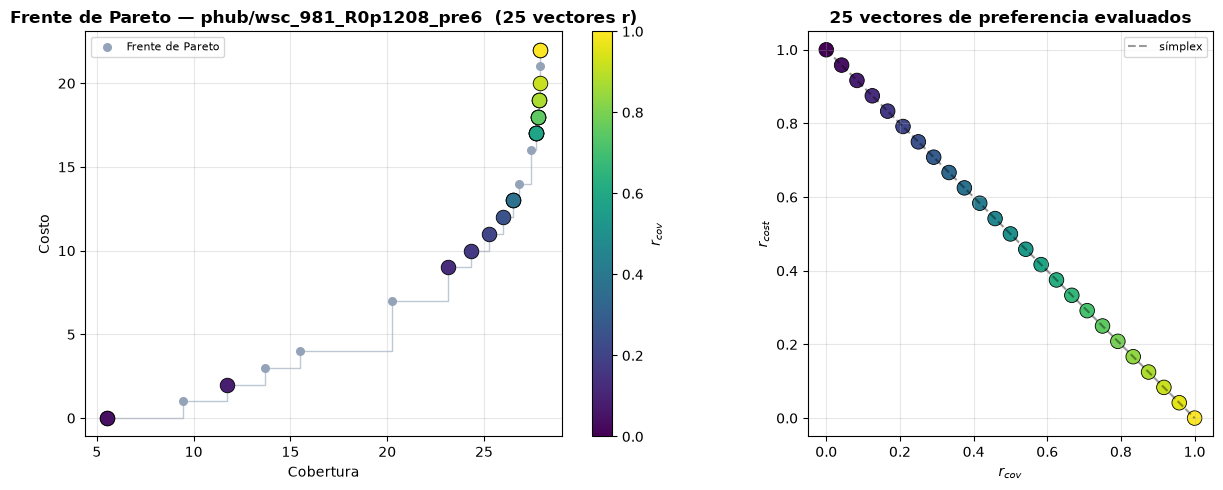

Instancia: phub/wsc_981_R0p1208_pre6  (19 puntos en el frente, 25 vectores r)
  r=(0.00, 1.00)  → idx  0  cobertura=5.5305  costo=0
  r=(0.04, 0.96)  → idx  0  cobertura=5.5305  costo=0
  r=(0.08, 0.92)  → idx  2  cobertura=11.7074  costo=2
  r=(0.12, 0.88)  → idx  6  cobertura=23.1232  costo=9
  r=(0.17, 0.83)  → idx  7  cobertura=24.3233  costo=10
  r=(0.21, 0.79)  → idx  8  cobertura=25.2751  costo=11
  r=(0.25, 0.75)  → idx  9  cobertura=25.9649  costo=12
  r=(0.29, 0.71)  → idx 10  cobertura=26.4969  costo=13
  r=(0.33, 0.67)  → idx 10  cobertura=26.4969  costo=13
  r=(0.38, 0.62)  → idx 10  cobertura=26.4969  costo=13
  r=(0.42, 0.58)  → idx 13  cobertura=27.6856  costo=17
  r=(0.46, 0.54)  → idx 13  cobertura=27.6856  costo=17
  r=(0.50, 0.50)  → idx 13  cobertura=27.6856  costo=17
  r=(0.54, 0.46)  → idx 13  cobertura=27.6856  costo=17
  r=(0.58, 0.42)  → idx 13  cobertura=27.6856  costo=17
  r=(0.62, 0.38)  → idx 14  cobertura=27.8085  costo=18
  r=(0.67, 0.33)  → idx 14  cobe

In [14]:
# Vectores de preferencia a evaluar, repartidos uniformemente en el símplex r_cov + r_cost = 1
N_VECTORS = 25   # cambia a 10, 20, etc.
r_cov_values = np.linspace(0.0, 1.0, N_VECTORS)
r_vectors = np.stack([r_cov_values, 1.0 - r_cov_values], axis=1)

inst = ds_train.instances[0]
obj  = inst["objectives"]
g    = inst["graph"]

coverage  = -obj[:, 0]              # cobertura real (positiva)
cost      =  obj[:, 1]
cov_norm  = coverage / g.cov_max
cost_norm = cost / g.n_candidates

cmap   = plt.cm.viridis
colors = cmap(r_vectors[:, 0])   # color según r_cov (0=azul → 1=amarillo)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: frente de Pareto con el punto elegido por cada r ─────────────────
ax = axes[0]
ax.step(coverage, cost, where='post', color='#94a3b8', alpha=0.6, linewidth=1, zorder=1)
ax.scatter(coverage, cost, color='#94a3b8', s=30, zorder=2, label='Frente de Pareto')

chosen_idx = []
for r, color in zip(r_vectors, colors):
    scores = r[0] * (1.0 - cov_norm) + r[1] * cost_norm
    best_idx = int(np.argmin(scores))
    chosen_idx.append(best_idx)
    ax.scatter(coverage[best_idx], cost[best_idx], color=color, s=110,
               edgecolors='black', linewidths=0.6, zorder=3)

ax.set_xlabel('Cobertura')
ax.set_ylabel('Costo')
ax.set_title(f'Frente de Pareto — {inst["name"]}  ({N_VECTORS} vectores r)', fontweight='bold')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='$r_{cov}$')

# ── Panel 2: los mismos r sobre el símplex ────────────────────────────────────
ax2 = axes[1]
ax2.plot([0, 1], [1, 0], 'k--', alpha=0.4, label='símplex')
ax2.scatter(r_vectors[:, 0], r_vectors[:, 1], c=colors, s=110,
            edgecolors='black', linewidths=0.6)
ax2.set_xlabel('$r_{cov}$')
ax2.set_ylabel('$r_{cost}$')
ax2.set_title(f'{N_VECTORS} vectores de preferencia evaluados', fontweight='bold')
ax2.set_aspect('equal')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
FIG_DIR = ROOT / 'data' / 'figures' / '03_preference_matching'
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / f'pref_vectors_on_front_{N_VECTORS}.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Instancia: {inst["name"]}  ({len(obj)} puntos en el frente, {N_VECTORS} vectores r)')
for r, idx in zip(r_vectors, chosen_idx):
    print(f'  r=({r[0]:.2f}, {r[1]:.2f})  → idx {idx:2d}  '
          f'cobertura={coverage[idx]:.4f}  costo={int(cost[idx])}')

n_unique = len(set(chosen_idx))
print(f'\n{n_unique}/{N_VECTORS} vectores mapearon a puntos distintos del frente '
      f'(el resto cayó en el mismo punto que algún vecino)')
print(f'✓ Imagen guardada en {FIG_DIR}/')

In [15]:
from collections import Counter

# Cuántos vectores de preferencia cayeron en cada punto del frente
idx_counts = Counter(chosen_idx)

print('Reparto de vectores de preferencia por punto del frente elegido:')
print(f'{"idx":>4}  {"cobertura":>10}  {"costo":>6}  {"n_vectores":>11}  vectores r (r_cov, r_cost)')
for idx in sorted(idx_counts, key=lambda i: cost[i]):
    rs_here = [r for r, i in zip(r_vectors, chosen_idx) if i == idx]
    rs_str  = ', '.join(f'({r[0]:.2f},{r[1]:.2f})' for r in rs_here)
    print(f'{idx:4d}  {coverage[idx]:10.4f}  {int(cost[idx]):6d}  {idx_counts[idx]:11d}  {rs_str}')

# Puntos que "absorbieron" más de un vector de preferencia
repeated = {idx: c for idx, c in idx_counts.items() if c > 1}
print(f'\n{len(repeated)}/{len(idx_counts)} puntos del frente fueron elegidos por más de un vector de preferencia')
for idx, c in sorted(repeated.items(), key=lambda kv: -kv[1]):
    print(f'  idx {idx:2d}  (cobertura={coverage[idx]:.4f}, costo={int(cost[idx])})  ← {c} vectores repiten esta solución')

Reparto de vectores de preferencia por punto del frente elegido:
 idx   cobertura   costo   n_vectores  vectores r (r_cov, r_cost)
   0      5.5305       0            2  (0.00,1.00), (0.04,0.96)
   2     11.7074       2            1  (0.08,0.92)
   6     23.1232       9            1  (0.12,0.88)
   7     24.3233      10            1  (0.17,0.83)
   8     25.2751      11            1  (0.21,0.79)
   9     25.9649      12            1  (0.25,0.75)
  10     26.4969      13            3  (0.29,0.71), (0.33,0.67), (0.38,0.62)
  13     27.6856      17            5  (0.42,0.58), (0.46,0.54), (0.50,0.50), (0.54,0.46), (0.58,0.42)
  14     27.8085      18            4  (0.62,0.38), (0.67,0.33), (0.71,0.29), (0.75,0.25)
  15     27.8618      19            3  (0.79,0.21), (0.83,0.17), (0.88,0.12)
  16     27.8858      20            1  (0.92,0.08)
  18     27.9119      22            2  (0.96,0.04), (1.00,0.00)

6/12 puntos del frente fueron elegidos por más de un vector de preferencia
  idx 13  (c